In [1]:
import pandas as pd

veri_yolu = r"C:\GitHub\credit-risk-scoring-project\veriler\application_train.csv"
df = pd.read_csv(veri_yolu)

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# 30.06.2026 tarihli çalışmada yaş ve cinsiyet değişkenlerinin risk durumları incelenecektir.
# Öncelikle yaş değişkeninin nasıl girilmiş olduğunu inceledim. 

In [2]:
df['DAYS_BIRTH'].head(20)

0     -9461
1    -16765
2    -19046
3    -19005
4    -19932
5    -16941
6    -13778
7    -18850
8    -20099
9    -14469
10   -10197
11   -20417
12   -13439
13   -14086
14   -14583
15    -8728
16   -12931
17    -9776
18   -17718
19   -11348
Name: DAYS_BIRTH, dtype: int64

In [6]:
# Bankalar yaş verisini, müşterinin kredi başvurusu yaptığı günü 0 noktası olarak alıp, doğduğu gün kadar bir gün eksilterek tutar.
# Bu değerleri daha kullanılabilir değerler haline getirdim.

In [7]:
df['AGE'] = round(df['DAYS_BIRTH'] / -365)

In [8]:
df['AGE'].describe()

count    307511.000000
mean         43.938646
std          11.964047
min          21.000000
25%          34.000000
50%          43.000000
75%          54.000000
max          69.000000
Name: AGE, dtype: float64

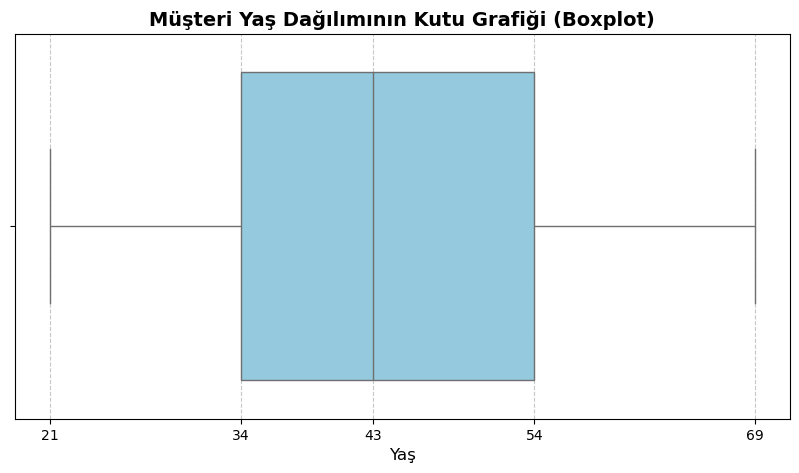

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(x=df['AGE'], color='skyblue')

kritik_degerler = [21, 34, 43, 54, 69]
plt.xticks(kritik_degerler)

plt.title('Müşteri Yaş Dağılımının Kutu Grafiği (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Yaş', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [11]:
# Grafikte ve tablo değerlerinde görüldüğü üzere; en küçük redi isteyen müşteri 21, en büyük 69 yaşında
# Kredi başvurusu yapan müşterilerin yaş ortalaması ise 42.

In [12]:
# Müşterileri 10'arlı yaş gruplarına ayırıp hangi grubun krediyi gerektirme riskinin daha yüksek olduğuna dair inceleme yaptım.

In [14]:
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 70])

# Hangi yaş grubunun yüzde kaç oranında krediyi geciktirdiğini (risk oranını) görelim.
df.groupby('AGE_GROUP', observed=False)['TARGET'].mean() * 100

AGE_GROUP
(20, 30]    11.444883
(30, 40]     9.434578
(40, 50]     7.581878
(50, 60]     6.036348
(60, 70]     4.924710
Name: TARGET, dtype: float64

In [15]:
# Görüldüğü üzere en riskli grup 20-30 yaş grubu: KRedilerini bu grubun %11.445'i geciktirmiş veya ödememiş.
# En az riskli grup ise 60-70 yaş grubu.

In [16]:
# Cinsiyete göre risk oranlarını inceleyelim.
df.groupby('CODE_GENDER')['TARGET'].mean() * 100

CODE_GENDER
F       6.999328
M      10.141920
XNA     0.000000
Name: TARGET, dtype: float64

In [17]:
# Cinsiyete göre en riskli grubun Erkek grubu olduğu görülüyor. Erkek müşterilerin %10.14'ü krediyi ödememiş veya geciktirmiş.
# Cinsiyet bilgisi girilmemiş yani XNA yazan müşterilerin risk oranı 0 çıkmış fakat kaç tane cinsiyet bilgisi olmayan
# müşteri olduğunu incelememiz gerekir.

In [18]:
df['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [ ]:
# Yalnızca 4 tane müşterinin cinsiyet bilgisi girilmediği için ilerleyen adımlarda bu satırları çıkaracağız.